# Homework 3 - Adversarial Attacks and Contrastive Learning

### Submission Guidelines

- This notebook contains all the questions. You should follow the instructions below.
- Solutions for the practical parts should be written in this notebook/py (see submission files) and for the dry "theoretical" parts in a pdf report.

You should submit the following files:
- Code files - You can choose 1 of the following options:
  - IPYNB notebook including the solutions to all 4 parts. The `.ipynb` file should not include any answers to dry questions because they should all be in the PDF report. Markdown cells in the notebook will not be checked.
  - PY files: 2 `.py` files, one for questions 1-3 and one for question 4. Submission format for `.py` files -  `HW3_Partn_ID1_ID2.py` where `n=1` is for parts 1-3 and `n=2` is for part 4.

- PDF file - report:
  - Answers for all the dry parts - analysis, visualization, dry questions, embeddings. You must create a PDF report, even if you chose to implement your code using a Jupyter Notebook. The PDF should not be a PDF version of the notebook and doesn't need to include any code.

Good Luck!

Libraries that can be used in this assignment:

- PyTorch (torch, torchvision, torch.optim, torch.nn, ...) -- Any other deep learning libraries such as keras are prohibited
- NumPy
- Any libraries used for visualization
- PIL (for image processing)

For any libraries other than those listed above, you may ask in the forum.

## Theory - Neural Network Expressivity (20pt)

Solve the following exercises rigorously. Note that your proof does not need to be typed (can be handwritten), and answers should be in the PDF report (not notebook).

### 1. The necessity of continuity for supremum ($L^\infty$) approximation.
Show that the Universal Approximation Theorem does not hold for discontinuous function under the supremum norm. Specifically, provide a counter-example $f$ that satisfies:
1. $f:[0,1]\to\mathbb{R}$ is bounded and has a **finite** set of discontinuities $\mathcal{D}$, but is continuous everywhere else in $[0,1]$.
2. There does not exist a depth-2 ReLU neural network $N$ such that for every $\epsilon>0$:
$$ \sup_{[0, 1]} |f(x)-N(x)| < \epsilon. $$

*Hint: ReLU networks are continuous functions in all of $\mathbb{R}$.*

### 2. Variation of UAT using $L^1$ approximation.
Let $f:[0,1]\to\mathbb{R}$ be a bounded function with a finite set of discontinuities $\mathcal{D}$. Prove that for any $\epsilon>0$, there exists a depth-2 ReLU network $N(x)$ such that:

$$\int_0^1 |f(x)-N(x)|dx < \epsilon. $$

In other words, we replaced the $L^\infty$ norm (for which the statement isn't true from part 1) with the $L^1$ norm.

**Proof Guideline:**
1. **Step function approximation (you don't have to do anything in this step):** Since $f$ is bounded with finitely many discontinuities, $f$ is Riemann integrable on $[0,1]$ so for any $\epsilon > 0$, there exists a step function
    $$S(x) = \sum_{j=1}^{m} c_j \mathbf{1}_{(a_{j-1}, a_j)}(x)$$
    where $0 = a_0 < a_1 < \cdots < a_m = 1$, such that $|f(x)-S(x)|<\frac{\epsilon}{2}$. Therefore,
    
    $$ \int_0^1 |f(x) - S(x)| dx < \frac{\epsilon}{2}$$

2. **Trapezoidal construction:** Show that an indicator function $1_{x\in (a,b)}$ can be approximated using a linear combination of four ReLU units by creating a trapezoid function $T_{a,b}^\delta(x)$ which returns $1$ for $x\in[a,b]$ and $0$ for $x\notin(a-\delta, b+\delta)$. Bound the $L^1$ distance between $1_{[a,b]}(x)$ and $T_{a,b}^\delta(x)$.
3. **Network Construction:** Define the network $N(x)$ using the trapezoidal functions and $\{c_j\}_{j=1}^m$.
    - Show why $N(x)$ is a valid depth-2 ReLU network.
    - Bound the $L^1$ distance $\int_0^1 |S(x)-N(x)|\,dx$. Note that using the triangle inequality, $\int_0^1 |S(x)-N(x)\le \int_0^1 \sum_{j=1}^m |c_j||1_{[a_j,a_{j+1}]}(x) - T_{a_j, a_{j+1}}^\delta(x)|\,dx$, which we can bound by switching the sum and the integral.
    - Determine the constraints on $\delta$ required to ensure the distance is less than $\frac{\epsilon}{2}$.
4. Put everything together using the triangle inequality.


## Part 1 - Training a CNN on SVHN (5pt)

Train a classifier on the dataset SVHN (Street View House Numbers), available through ```torchvision.datasets```. The model accuracy should reach at least 90% on the test set. You're free to add as many data augmentations as necessary. Take into consideration that any serious augmentations (like normalization) should be reversed when displaying images in future sections.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import SVHN
import torchvision.transforms as transforms

# ----------------------------
# Setup
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# SVHN normalization (common)
MEAN = (0.4377, 0.4438, 0.4728)
STD  = (0.1980, 0.2010, 0.1970)

# ----------------------------
# Transforms (with augmentation)
# ----------------------------
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Unnormalize helper (for later sections when displaying images)
def unnormalize(x, mean=MEAN, std=STD):
    # x: Tensor [C,H,W] or [B,C,H,W]
    mean_t = torch.tensor(mean, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    std_t  = torch.tensor(std, dtype=x.dtype, device=x.device).view(1, 3, 1, 1)
    if x.dim() == 3:
        return (x.unsqueeze(0) * std_t + mean_t).squeeze(0)
    return x * std_t + mean_t

# ----------------------------
# Data
# ----------------------------
train_ds = SVHN(root="./data", split="train", download=True, transform=train_tf)
test_ds  = SVHN(root="./data", split="test",  download=True, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
class SVHNCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),  # 4x4
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.feat(x)
        x = x.view(x.size(0), -1)
        return self.head(x)

model = SVHNCNN().to(device)

# ----------------------------
# Train / Eval
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

@torch.no_grad()
def test_accuracy():
    model.eval()
    correct, total = 0, 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

EPOCHS = 3
best_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    acc = test_accuracy()
    if acc > best_acc:
        best_acc = acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch:02d}: test acc = {acc*100:.2f}% (best {best_acc*100:.2f}%)")

if best_state is not None:
    model.load_state_dict(best_state)

final_acc = test_accuracy()
print(f"\nFinal test accuracy: {final_acc*100:.2f}%")
assert final_acc >= 0.90, "Did not reach 90% test accuracy. Try more epochs/augmentations or tune LR."

100%|██████████| 182M/182M [00:29<00:00, 6.18MB/s]
100%|██████████| 64.3M/64.3M [00:13<00:00, 4.93MB/s]


Epoch 01: test acc = 88.06% (best 88.06%)
Epoch 02: test acc = 91.45% (best 91.45%)
Epoch 03: test acc = 91.99% (best 91.99%)

Final test accuracy: 91.99%


### Analysis

Analyze the performance of the model on the test set (e.g. through a confusion matrix). Display at least 4 images that the model predicts incorrectly and their predicted classes. Discuss possible weaknesses of the model and their causes.

<Figure size 800x800 with 0 Axes>

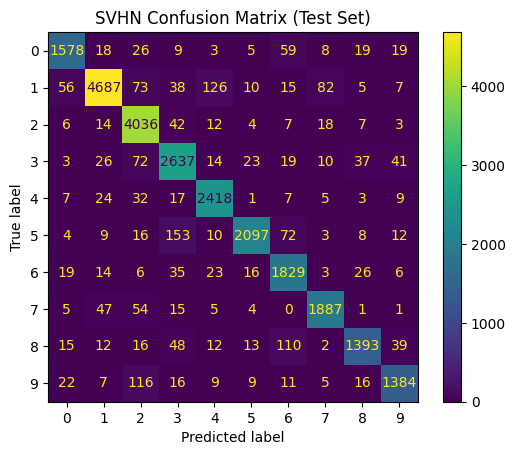

Classification Report (per class):
              precision    recall  f1-score   support

           0     0.9201    0.9048    0.9124      1744
           1     0.9648    0.9192    0.9414      5099
           2     0.9076    0.9728    0.9390      4149
           3     0.8761    0.9150    0.8951      2882
           4     0.9187    0.9584    0.9381      2523
           5     0.9610    0.8796    0.9185      2384
           6     0.8591    0.9251    0.8909      1977
           7     0.9328    0.9346    0.9337      2019
           8     0.9195    0.8392    0.8775      1660
           9     0.9099    0.8677    0.8883      1595

    accuracy                         0.9199     26032
   macro avg     0.9170    0.9116    0.9135     26032
weighted avg     0.9213    0.9199    0.9198     26032



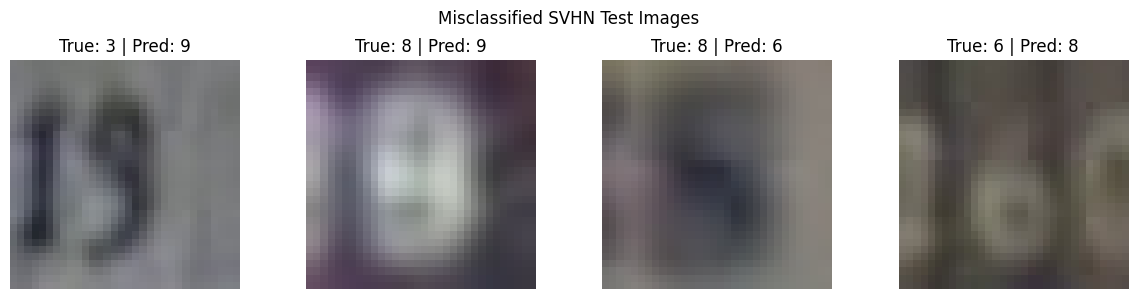

In [2]:
# ============================
# Analysis (Test Set)
# ============================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

@torch.no_grad()
def collect_preds_targets(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

# 1) Confusion Matrix
preds, targets = collect_preds_targets(model, test_loader, device)

cm = confusion_matrix(targets, preds, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

plt.figure(figsize=(8, 8))
disp.plot(cmap=None, values_format="d")
plt.title("SVHN Confusion Matrix (Test Set)")
plt.show()

# Optional but useful: per-class metrics (precision/recall/F1)
print("Classification Report (per class):")
print(classification_report(targets, preds, digits=4))


# 2) Show at least 4 misclassified images
@torch.no_grad()
def show_misclassified_images(model, loader, device, k=4):
    model.eval()
    mis = []  # (image_tensor, true_label, pred_label)

    for x, y in loader:
        x_dev = x.to(device)
        y_dev = y.to(device)

        logits = model(x_dev)
        pred = logits.argmax(dim=1)

        wrong = pred.ne(y_dev)
        if wrong.any():
            idxs = wrong.nonzero(as_tuple=False).squeeze(1).cpu().tolist()
            for i in idxs:
                mis.append((x[i].cpu(), int(y[i].cpu()), int(pred[i].cpu())))

        if len(mis) >= k:   # stop once we have enough
            break

    k = min(k, len(mis))
    if k == 0:
        print("No misclassified images were found (unlikely).")
        return

    plt.figure(figsize=(3*k, 3))
    for j in range(k):
        img, y_true, y_pred = mis[j]

        # reverse normalization for display
        img_disp = unnormalize(img).clamp(0, 1)        # [C,H,W]
        img_disp = img_disp.permute(1, 2, 0).numpy()   # [H,W,C]

        ax = plt.subplot(1, k, j+1)
        ax.imshow(img_disp)
        ax.set_title(f"True: {y_true} | Pred: {y_pred}")
        ax.axis("off")

    plt.suptitle("Misclassified SVHN Test Images")
    plt.tight_layout()
    plt.show()

show_misclassified_images(model, test_loader, device, k=4)

## Part 2: Adversarial Attacks on our Model (15pt)

### Dry Question
In Slide 14 of the tutorial on adversarial attacks, we showed how attacks can be transfered from one model to another, i.e. if we craft an attack for ResNet50 using FGSM, it will likely also confuse other models. Why is this property important, specifically when attacking an unknown model?

Implement the FGSM algorithm as shown in the tutorial (it may be necessary to make require_grad be True for our input data in order to calculate its gradient). Define a function ```eval_adversarial(model, test_loader, epsilon)``` that applies FGSM on the test data by creating new images which are perturbed versions of the originals, and calculates the model's accuracy only on the perturbed images. Test accuracy after the attack should be less than 25% for $\varepsilon=0.1$.

In [3]:
import torch
import torch.nn.functional as F
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Device + model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

mean = torch.tensor([0.4377, 0.4438, 0.4728], device=device).view(1, 3, 1, 1)
std  = torch.tensor([0.1980, 0.2010, 0.1970], device=device).view(1, 3, 1, 1)



def fgsm(x_norm, epsilon, grad_norm):
    # 1) Unnormalize to pixel space [0,1]
    x_pix = x_norm * std + mean

    # 2) FGSM step in pixel space
    x_adv_pix = x_pix + epsilon * grad_norm.sign()

    # 3) Keep valid pixels
    x_adv_pix = torch.clamp(x_adv_pix, 0.0, 1.0)

    # 4) Normalize back (so model gets normalized input)
    x_adv_norm = (x_adv_pix - mean) / std
    return x_adv_norm

def eval_adversarial(model, test_loader, epsilon):
    model.eval()
    correct, total = 0, 0

    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # need gradient w.r.t. input
        inputs = inputs.detach().requires_grad_(True)

        # forward + loss
        outputs = model(inputs)
        loss = F.cross_entropy(outputs, labels)

        # backward to get grad on inputs
        model.zero_grad(set_to_none=True)
        if inputs.grad is not None:
            inputs.grad.zero_()
        loss.backward()

        # create adversarial examples
        grads = inputs.grad.detach()
        adv_inputs = fgsm(inputs.detach(), epsilon, grads)

        # evaluate on adversarial only
        with torch.no_grad():
            outputs_adv = model(adv_inputs)
            preds = outputs_adv.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100.0 * correct / total
    print(f"Accuracy after FGSM attack (epsilon={epsilon}): {acc:.2f}%")
    return acc

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))
])

test_dataset = SVHN(root='./data', split='test', download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Run
epsilon = 0.1
eval_adversarial(model, test_loader, epsilon)


Accuracy after FGSM attack (epsilon=0.1): 2.83%


2.8349723417332515

### Visualization

Visualize some images that the model got right before the perturbation and wrong after the attack. Create a confusion matrix of the output on the entire test set (looking only at the perturbed images).

Test the function with different values of epsilon (at least 5) and plot the accuracy as a function of epsilon. For each epsilon, display the perturbed images with the model's classification. At what epsilon does it become harder for the human eye to correctly classify?

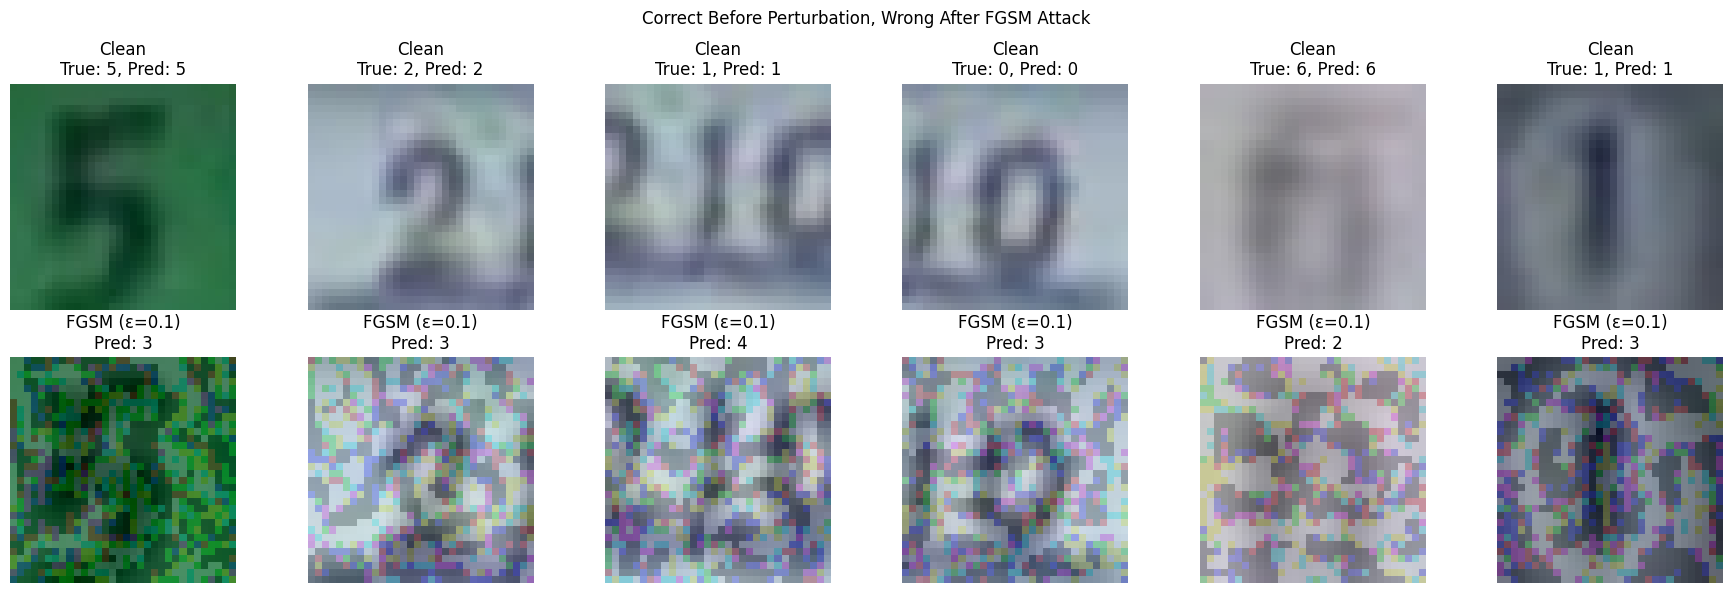

In [4]:
# Visualization of FGSM Adversarial Examples:
# Samples Correctly Classified on Clean Images but Misclassified After FGSM Attack
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def predict_labels(model, x):
    return model(x).argmax(dim=1)

def show_correct_before_wrong_after(model, test_loader, epsilon, device, num_images=6):
    model.eval()
    collected = []

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        # clean prediction
        preds_clean = predict_labels(model, x)

        # compute grads for FGSM
        x_for_grad = x.detach().clone().requires_grad_(True)
        outputs = model(x_for_grad)
        loss = F.cross_entropy(outputs, y)

        model.zero_grad(set_to_none=True)
        if x_for_grad.grad is not None:
            x_for_grad.grad.zero_()
        loss.backward()

        grads = x_for_grad.grad.detach()
        x_adv = fgsm(x_for_grad.detach(), epsilon, grads).detach()

        # adversarial prediction
        preds_adv = predict_labels(model, x_adv)

        # correct before, wrong after
        mask = (preds_clean == y) & (preds_adv != y)
        if mask.any():
            idxs = mask.nonzero(as_tuple=False).squeeze(1).tolist()
            for i in idxs:
                collected.append((
                    x[i].detach().cpu(),
                    x_adv[i].detach().cpu(),
                    int(y[i].item()),
                    int(preds_clean[i].item()),
                    int(preds_adv[i].item())
                ))
                if len(collected) >= num_images:
                    break
        if len(collected) >= num_images:
            break

    if len(collected) == 0:
        print("No suitable examples found.")
        return

    # plot
    plt.figure(figsize=(3 * len(collected), 6))
    for i, (x_clean, x_adv_img, y_true, p_clean, p_adv) in enumerate(collected):
        img_clean = unnormalize(x_clean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax1 = plt.subplot(2, len(collected), i + 1)
        ax1.imshow(img_clean)
        ax1.set_title(f"Clean\nTrue: {y_true}, Pred: {p_clean}")
        ax1.axis("off")

        img_adv = unnormalize(x_adv_img).clamp(0, 1).permute(1, 2, 0).numpy()
        ax2 = plt.subplot(2, len(collected), i + 1 + len(collected))
        ax2.imshow(img_adv)
        ax2.set_title(f"FGSM (ε={epsilon})\nPred: {p_adv}")
        ax2.axis("off")

    plt.suptitle("Correct Before Perturbation, Wrong After FGSM Attack")
    plt.tight_layout()
    plt.show()

# usage
show_correct_before_wrong_after(model, test_loader, epsilon=0.1, device=device, num_images=6)


<Figure size 800x800 with 0 Axes>

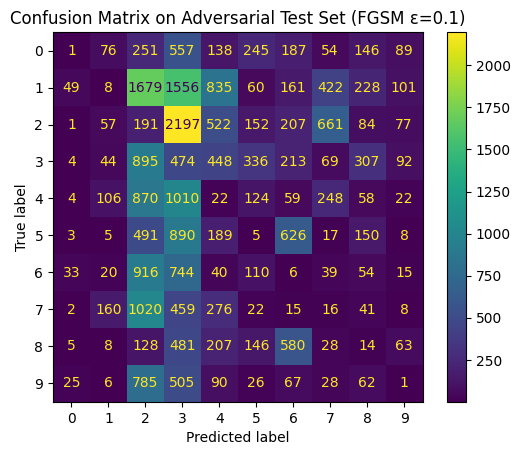

In [5]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================
# 3) Confusion Matrix on the ENTIRE test set (adversarial images only)
# ============================

def collect_adv_preds_targets(model, test_loader, epsilon, device):
    model.eval()
    all_preds, all_targets = [], []

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        # ---- compute grads wrt input (needed for FGSM) ----
        x_for_grad = x.detach().clone().requires_grad_(True)

        outputs = model(x_for_grad)
        loss = F.cross_entropy(outputs, y)

        model.zero_grad(set_to_none=True)
        if x_for_grad.grad is not None:
            x_for_grad.grad.zero_()
        loss.backward()

        grads = x_for_grad.grad.detach()

        x_adv = fgsm(x_for_grad.detach(), epsilon, grads).detach()

        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)

        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    return preds, targets


def plot_adv_confusion_matrix(model, test_loader, epsilon, device):
    """
    Creates and plots a confusion matrix using ONLY FGSM-perturbed test images.
    """
    preds, targets = collect_adv_preds_targets(model, test_loader, epsilon, device)

    cm = confusion_matrix(targets, preds, labels=list(range(10)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

    plt.figure(figsize=(8, 8))
    disp.plot(cmap=None, values_format="d")
    plt.title(f"Confusion Matrix on Adversarial Test Set (FGSM ε={epsilon})")
    plt.show()


plot_adv_confusion_matrix(model, test_loader, epsilon=0.1, device=device)


epsilon=0.00 | accuracy on perturbed test set: 91.99%


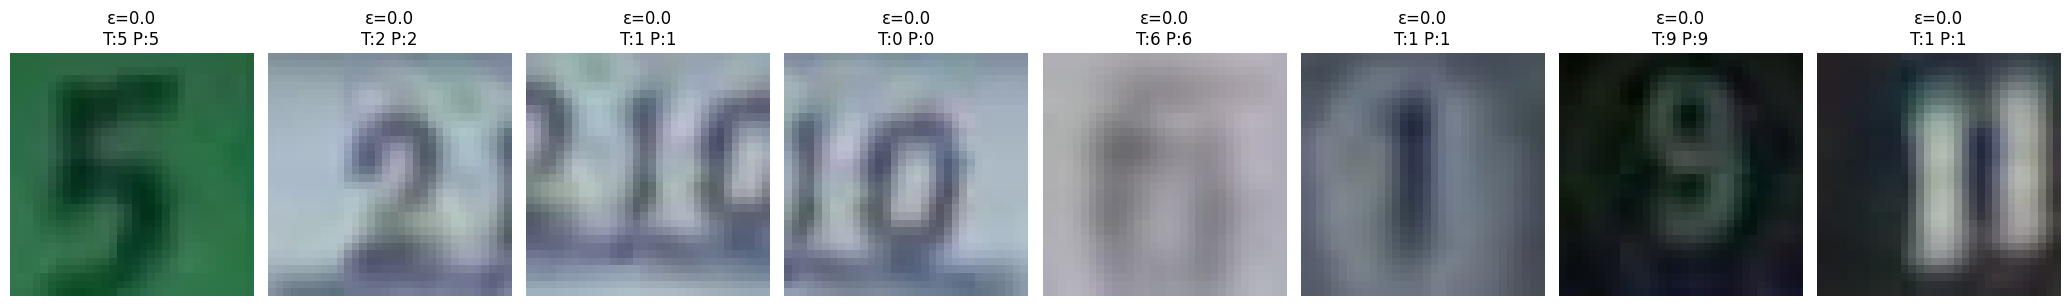

epsilon=0.02 | accuracy on perturbed test set: 23.23%


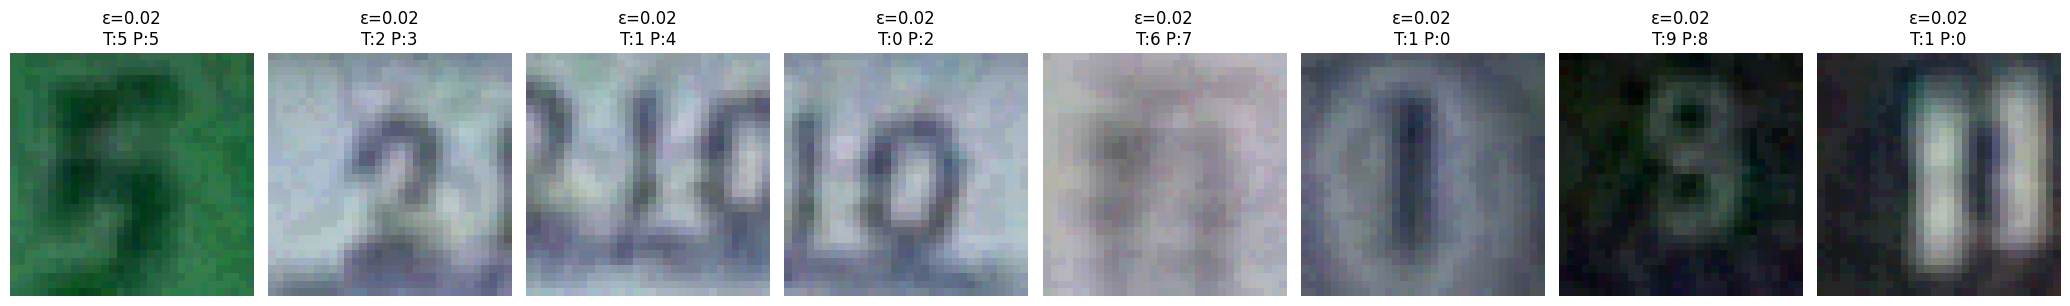

epsilon=0.05 | accuracy on perturbed test set: 4.29%


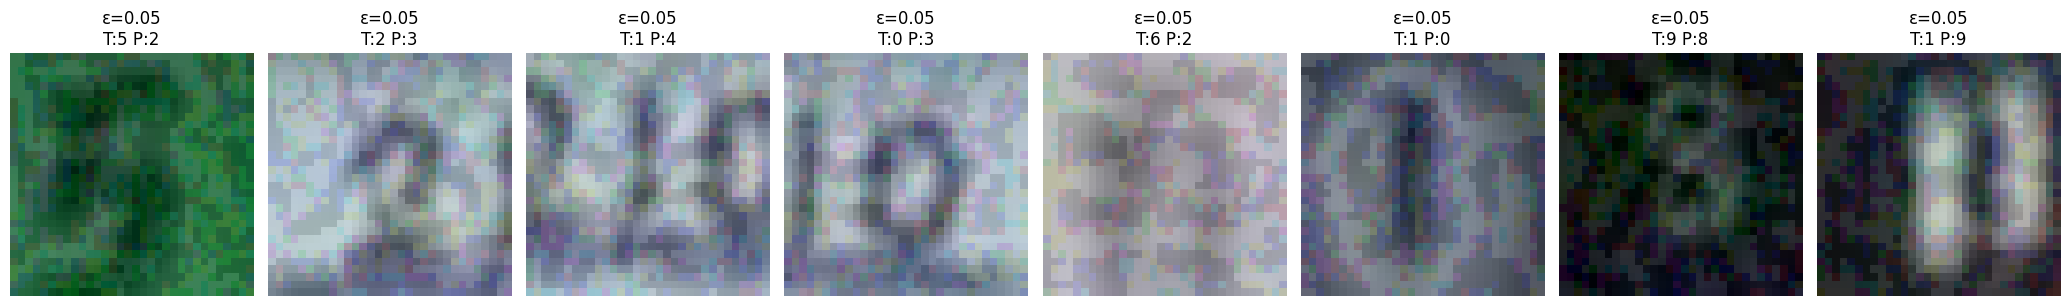

epsilon=0.10 | accuracy on perturbed test set: 2.83%


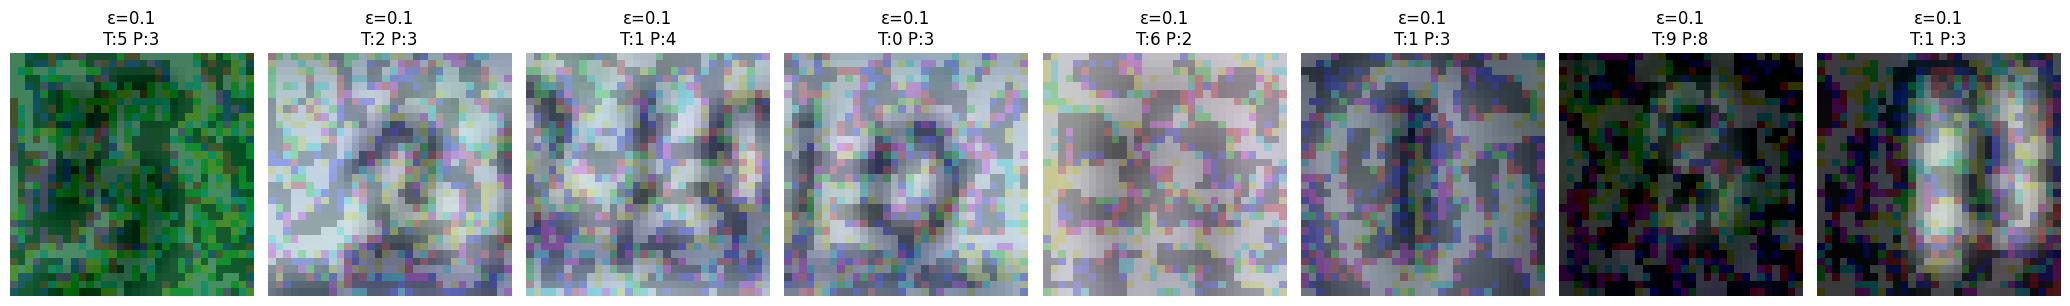

epsilon=0.15 | accuracy on perturbed test set: 4.08%


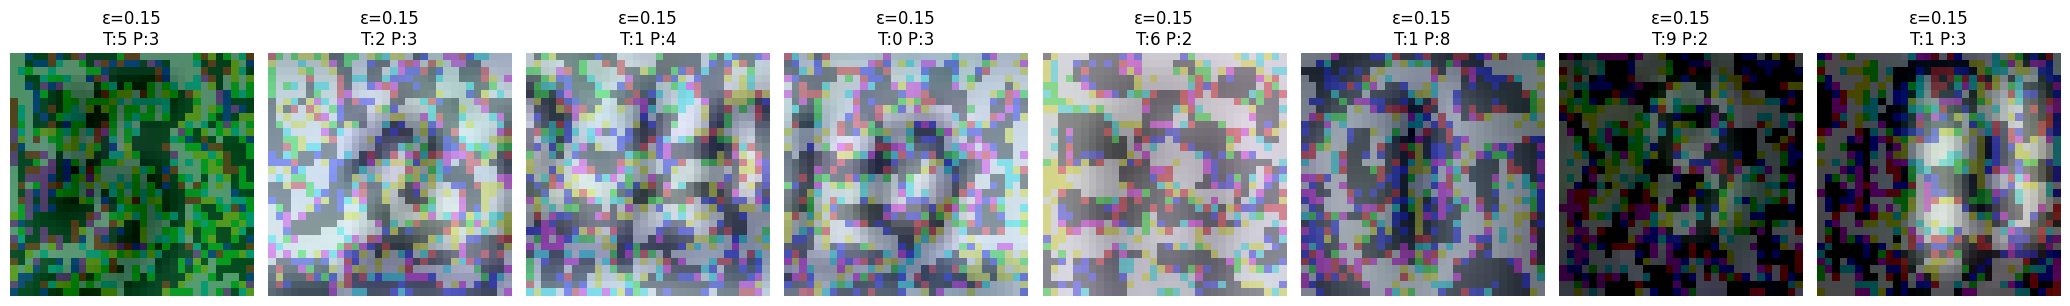

epsilon=0.20 | accuracy on perturbed test set: 5.52%


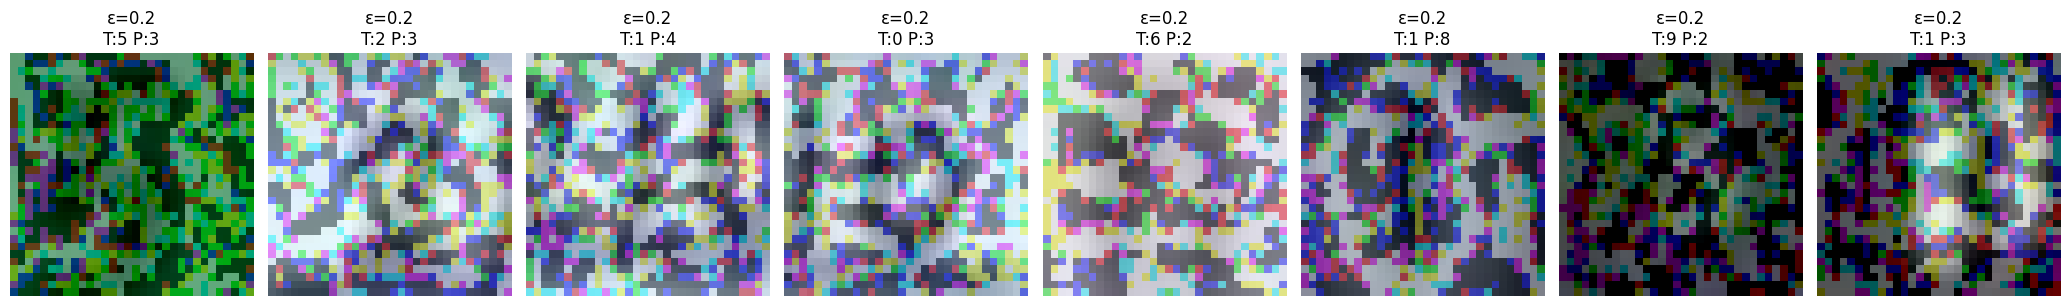

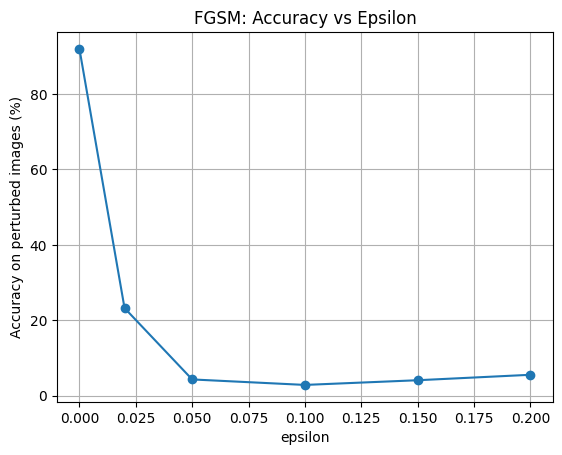

In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def make_adv_batch(model, x, y, epsilon):

    model.eval()

    x_for_grad = x.detach().requires_grad_(True)
    logits = model(x_for_grad)
    loss = F.cross_entropy(logits, y)

    model.zero_grad(set_to_none=True)
    if x_for_grad.grad is not None:
        x_for_grad.grad.zero_()
    loss.backward()

    grads = x_for_grad.grad.detach()
    x_adv = fgsm(x_for_grad.detach(), epsilon, grads).detach()
    return x_adv

def eval_adversarial(model, test_loader, epsilon):
    model.eval()
    correct, total = 0, 0

    for x, y in test_loader:
        x = x.to(device)
        y = torch.as_tensor(y, device=device).long()

        # create adversarial images (needs grad)
        x_adv = make_adv_batch(model, x, y, epsilon)

        # evaluate on adversarial only (no grad needed)
        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total

def show_perturbed_images_with_preds(model, test_loader, epsilon, num_images=8):
    model.eval()
    x, y = next(iter(test_loader))
    x = x.to(device)
    y = torch.as_tensor(y, device=device).long()

    # needs grad
    x_adv = make_adv_batch(model, x, y, epsilon)

    with torch.no_grad():
        preds = model(x_adv).argmax(dim=1)

    k = min(num_images, x_adv.size(0))
    plt.figure(figsize=(2.6 * k, 3.2))
    for i in range(k):
        img = unnormalize(x_adv[i].detach().cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        ax = plt.subplot(1, k, i + 1)
        ax.imshow(img)
        ax.set_title(f"ε={epsilon}\nT:{int(y[i].cpu())} P:{int(preds[i].cpu())}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Test for >= 5 epsilons + plot accuracy vs epsilon
# ---------------------------------------------------------
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2]  # >=5 values

accs = []
for eps in epsilons:
    acc = eval_adversarial(model, test_loader, eps)
    accs.append(acc)
    print(f"epsilon={eps:.2f} | accuracy on perturbed test set: {acc*100:.2f}%")

    show_perturbed_images_with_preds(model, test_loader, eps, num_images=8)

plt.figure()
plt.plot(epsilons, [a * 100 for a in accs], marker="o")
plt.xlabel("epsilon")
plt.ylabel("Accuracy on perturbed images (%)")
plt.title("FGSM: Accuracy vs Epsilon")
plt.grid(True)
plt.show()


## Part 3: Training our model using adversarial training (20pt)

For each point in the training data, increase the model's robustness by training not only on the point itself, but on the perturbed point after the FGSM algorithm using $\varepsilon=0.1$. Afterwards, compute the accuracy once again on the newly trained model using ```eval_adversarial(model, test_loader, epsilon)``` defined above. The accuracy **looking only at the perterubed data** should be at least 70%.

In [16]:
import torch
import torch.nn.functional as F

epsilon = 0.1
epochs = 15
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    n = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = torch.as_tensor(y, device=device).long()

        x_for_grad = x.detach().requires_grad_(True)
        logits_tmp = model(x_for_grad)
        loss_tmp = F.cross_entropy(logits_tmp, y)

        grads = torch.autograd.grad(loss_tmp, x_for_grad, create_graph=False, retain_graph=False)[0]
        x_adv = fgsm(x_for_grad.detach(), epsilon, grads.detach()).detach()

        logits_clean = model(x.detach())
        loss_clean = F.cross_entropy(logits_clean, y)

        logits_adv = model(x_adv)
        loss_adv = F.cross_entropy(logits_adv, y)

        loss = 0.5 * (loss_clean + loss_adv)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        n += y.size(0)

    print(f"Epoch {epoch:02d}/{epochs} | train loss: {running_loss / n:.4f}")

    adv_acc = eval_adversarial(model, test_loader, epsilon)
    if adv_acc <= 1.0:
        print(f"Epoch {epoch:02d} | TEST adv acc (eps={epsilon}): {adv_acc*100:.2f}%\n")
    else:
        print(f"Epoch {epoch:02d} | TEST adv acc (eps={epsilon}): {adv_acc:.2f}%\n")


Epoch 01/15 | train loss: 0.1522
Epoch 01 | TEST adv acc (eps=0.1): 97.23%

Epoch 02/15 | train loss: 0.1277
Epoch 02 | TEST adv acc (eps=0.1): 96.88%

Epoch 03/15 | train loss: 0.1145
Epoch 03 | TEST adv acc (eps=0.1): 97.93%

Epoch 04/15 | train loss: 0.1057
Epoch 04 | TEST adv acc (eps=0.1): 97.62%

Epoch 05/15 | train loss: 0.1001
Epoch 05 | TEST adv acc (eps=0.1): 97.50%

Epoch 06/15 | train loss: 0.0939
Epoch 06 | TEST adv acc (eps=0.1): 97.42%

Epoch 07/15 | train loss: 0.0893
Epoch 07 | TEST adv acc (eps=0.1): 97.33%

Epoch 08/15 | train loss: 0.0859
Epoch 08 | TEST adv acc (eps=0.1): 96.40%

Epoch 09/15 | train loss: 0.0838
Epoch 09 | TEST adv acc (eps=0.1): 97.36%

Epoch 10/15 | train loss: 0.0803
Epoch 10 | TEST adv acc (eps=0.1): 97.57%

Epoch 11/15 | train loss: 0.0766
Epoch 11 | TEST adv acc (eps=0.1): 94.54%

Epoch 12/15 | train loss: 0.0767
Epoch 12 | TEST adv acc (eps=0.1): 93.60%

Epoch 13/15 | train loss: 0.0712
Epoch 13 | TEST adv acc (eps=0.1): 94.76%

Epoch 14/15 

### Visualization

Display the confusion matrix along with some examples of images that the model classified incorrectly. Discuss the performance of the model now compared to before.

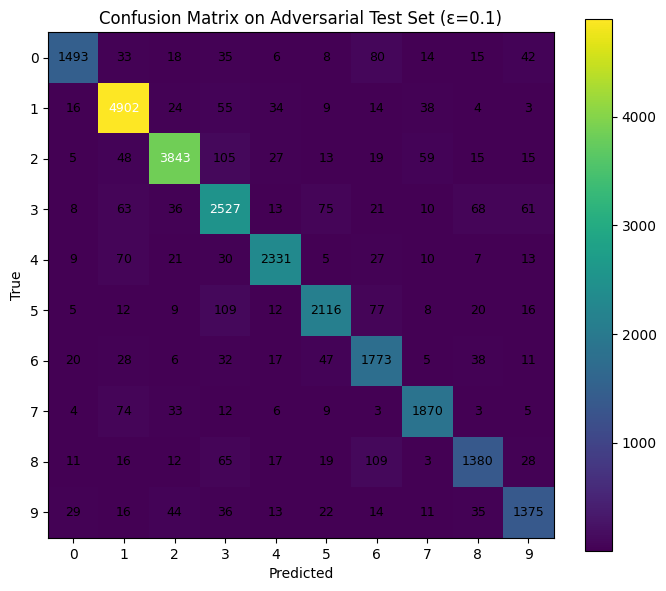

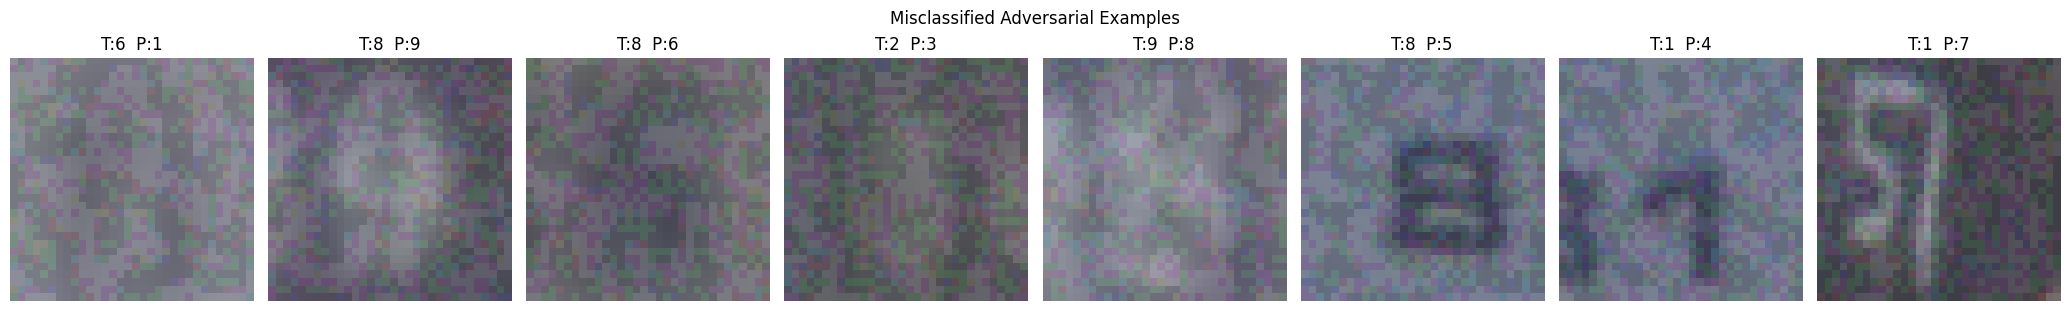

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Collect predictions on adversarial test set
# -------------------------------------------------
def collect_adv_predictions(model, test_loader, epsilon):
    model.eval()
    y_true_all = []
    y_pred_all = []
    wrong_samples = []

    for x, y in test_loader:
        x = x.to(device)
        y = torch.as_tensor(y, device=device).long()

        x_for_grad = x.detach().requires_grad_(True)
        logits = model(x_for_grad)
        loss = F.cross_entropy(logits, y)

        model.zero_grad(set_to_none=True)
        if x_for_grad.grad is not None:
            x_for_grad.grad.zero_()
        loss.backward()

        grads = x_for_grad.grad.detach()
        x_adv = fgsm(x_for_grad.detach(), epsilon, grads).detach()

        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)

        y_true_all.append(y.detach().cpu())
        y_pred_all.append(preds.detach().cpu())

        wrong_mask = preds != y
        if wrong_mask.any():
            idxs = wrong_mask.nonzero(as_tuple=False).squeeze(1)
            for i in idxs:
                wrong_samples.append((
                    x_adv[i].detach().cpu(),
                    int(y[i].item()),
                    int(preds[i].item())
                ))

    y_true_all = torch.cat(y_true_all).numpy()
    y_pred_all = torch.cat(y_pred_all).numpy()
    return y_true_all, y_pred_all, wrong_samples


# -------------------------------------------------
# Confusion Matrix
# -------------------------------------------------
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(np.arange(10), [str(i) for i in range(10)])
    plt.yticks(np.arange(10), [str(i) for i in range(10)])

    max_val = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > max_val / 2 else "black",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Show misclassified adversarial images
# -------------------------------------------------
def show_wrong_examples(wrong_samples, num_images=8):
    k = min(num_images, len(wrong_samples))
    if k == 0:
        print("No misclassified adversarial examples found.")
        return

    plt.figure(figsize=(2.6 * k, 3.2))
    for i in range(k):
        img, y_true, y_pred = wrong_samples[i]
        img = unnormalize(img).clamp(0, 1).permute(1, 2, 0).numpy()

        ax = plt.subplot(1, k, i + 1)
        ax.imshow(img)
        ax.set_title(f"T:{y_true}  P:{y_pred}")
        ax.axis("off")

    plt.suptitle("Misclassified Adversarial Examples")
    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Run visualization
# -------------------------------------------------
epsilon = 0.1

y_true, y_pred, wrong_samples = collect_adv_predictions(
    model, test_loader, epsilon
)

cm = np.zeros((10, 10), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

plot_confusion_matrix(cm, title=f"Confusion Matrix on Adversarial Test Set (ε={epsilon})")
show_wrong_examples(wrong_samples, num_images=8)




## Part 4: Contrastive Learning (40pt)

In this section, we will work on creating informative embeddings for images using SimCLR. For this section we will use the subset of the popular ImageNet dataset of 96x96 images from 1000 classes. Below, we provide you with several functions to implement a contrastive learning model.

The data is already downloaded to your VMs in the zip tiny-imagenet-200. You can also find it at https://www.kaggle.com/datasets/nikhilshingadiya/tinyimagenet200/data. Note that training time in this section can be long, $\approx 5$ minutes for epoch.

### Dry Questions

Before implementation, take these questions in consideration (and provide your answers and explanations):

1. When training an unsupervised contrastive learning model such as SimCLR, would we prefer to have a large or small batch size?
2. When creating embeddings for images in the test set, how does the process differ from what we do in training?
3. For each of the following image augmentations, explain whether or not we would like to use them in the SimCLR framework:
    - Randomly cropping a fixed-size window in the image.
    - Enlarging the image to 128x128.
    - Random rotation of the image.
    - Adding Gaussian noise.
    - Randomly changing the image's dimensions.
    - Randomly converting the image to grayscale.

### Code

Do the following:

1. Create a CNN that makes embeddings for images (you can use pretrained foundation models if you'd like, as long as they **were not** trained on ImageNet).
2. Implement an unsupervised contrastive loss (such as nt-xent in SimCLR).
3. Train the model (achieve loss less than 3.0). Use only the train set.

Note you are graded not only on the loss but also on the quality of the embeddings. If the augmentations aren't diverse enough, the loss may be low but similar images won't learn to be mapped to similar embeddings. You must use at least 3 random augmentations in the SimCLR training (the more, the better).

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.manifold import TSNE  # dimensionality reduction

# =========================
# Paths + batch size
# =========================
TRAIN_PATH = "/content/tiny-imagenet-200/train/"
TEST_PATH  = "/content/tiny-imagenet-200/test/"

# SimCLR typically prefers large batches; pick a realistic one for your GPU
BATCH_SIZE = 64
LEARNING_RATE = 5e-4


In [ ]:
class TrainDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        """
        Initialize the dataset with the root directory and the transform to be applied.
        """
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            if os.path.isdir(os.path.join(root, label, 'images')):
                for img in os.listdir(os.path.join(root, label, 'images')):
                    self.imgs.append(os.path.join(root, label, 'images', img))

    def __len__(self):
        """
        Return the length of the dataset.
        """
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Fetch the image and apply two different augmentations to it.
        """
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert('RGB')  # Ensure it's in RGB format

        if self.transform:
            img1 = self.transform(img)  # First random augmentation
            img2 = self.transform(img)  # Second random augmentation
        else:
            img1, img2 = img, img

        return img1, img2  # Return both augmented versions


class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.imgs = []
        for label in os.listdir(root):
            for img in os.listdir(os.path.join(root, label)):
                self.imgs.append(os.path.join(root, label, img))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img_transform = self.transform(img)
        return transforms.ToTensor()(img), img_transform  # Return the original image (for visualization) and the image that will be used in the model


data_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=96, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.2)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    # optional but useful (uncomment if you want)
    # transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_data = TrainDataset(TRAIN_PATH, transform=data_transforms)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

test_data = TestDataset(TEST_PATH, transform=test_transforms)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

Using the function ```plot_embeddings```, show the model's performance on the test data.

✅ device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


🚀 Starting Training 🚀
Epoch [1/10], Loss: 2.6677
Epoch [2/10], Loss: 1.3344
Epoch [3/10], Loss: 1.0300
Epoch [4/10], Loss: 0.8714
Epoch [5/10], Loss: 0.7756
Epoch [6/10], Loss: 0.7132
Epoch [7/10], Loss: 0.6546
Epoch [8/10], Loss: 0.6069
Epoch [9/10], Loss: 0.5686
Epoch [10/10], Loss: 0.5290
💾 Model saved successfully!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


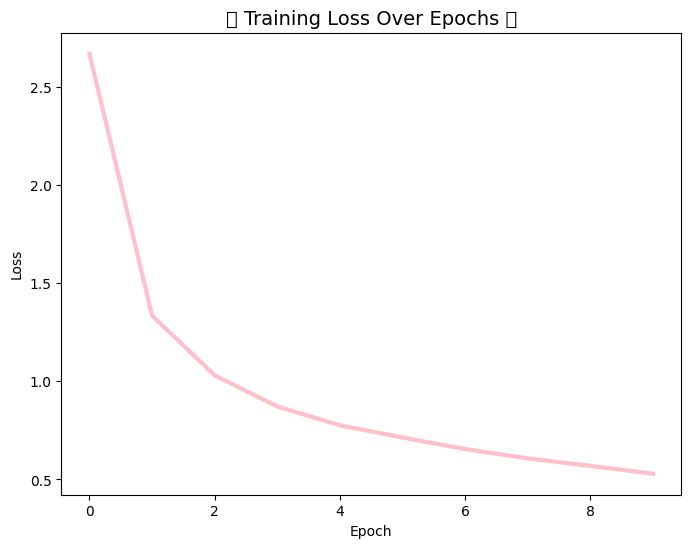

🖼️ Visualizing embeddings on test data...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


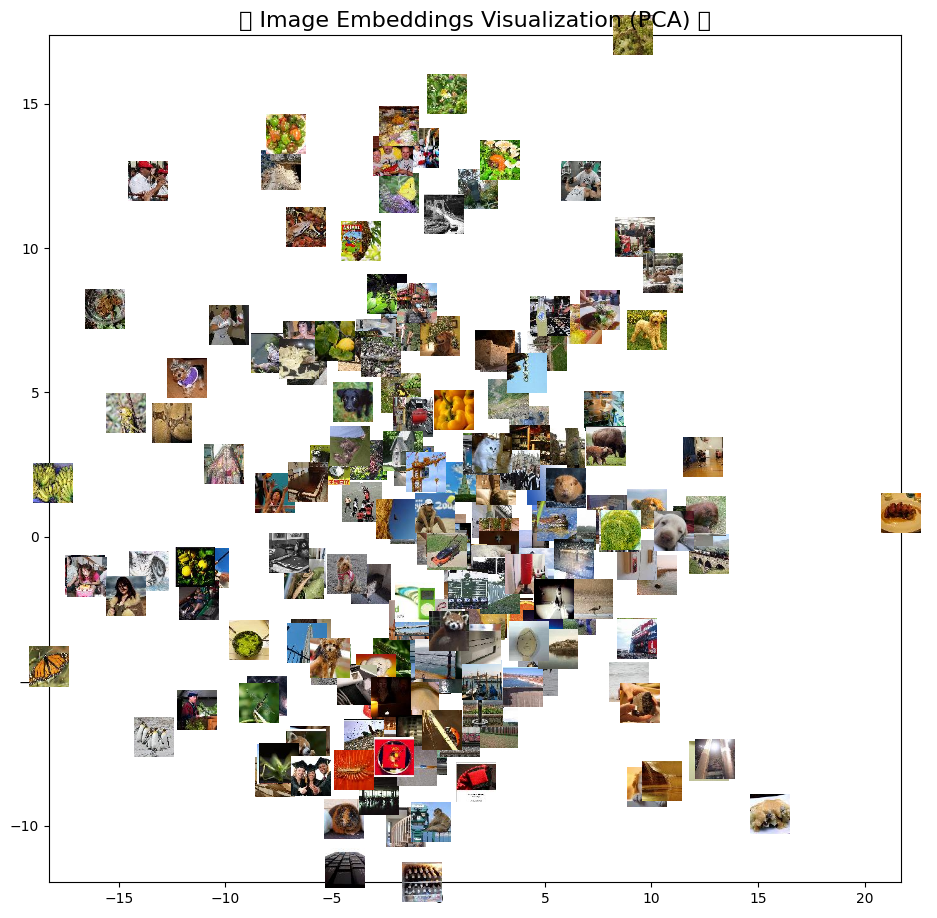

✅ Embeddings visualized!


In [ ]:
# =========================
# Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import models
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA


# =========================
# Embedding Model (fast backbone)
# =========================
class EmbeddingModel(nn.Module):
    def __init__(self, pretrained: bool = False, out_dim: int = 128):
        super().__init__()
        backbone = models.resnet18(pretrained=pretrained)  # faster than resnet50
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.proj = nn.Linear(backbone.fc.in_features, out_dim)

    def forward(self, x):
        x = self.backbone(x)
        x = torch.flatten(x, 1)
        x = self.proj(x)
        return x


# =========================
# NT-Xent Loss
# =========================
class ContrastiveLoss(nn.Module):
    def __init__(self, temp: float = 0.1, eps: float = 1e-8):
        super().__init__()
        self.temp = temp
        self.eps = eps

    def forward(self, emb1, emb2):
        z1 = F.normalize(emb1, dim=1)
        z2 = F.normalize(emb2, dim=1)

        B = z1.size(0)
        z = torch.cat([z1, z2], dim=0)  # [2B, D]

        sim = torch.mm(z, z.t()) / self.temp
        sim = torch.exp(sim)

        diag = torch.eye(2 * B, device=sim.device, dtype=torch.bool)
        sim = sim.masked_fill(diag, 0.0)

        pos = torch.exp(torch.sum(z1 * z2, dim=1) / self.temp)  # [B]
        pos = torch.cat([pos, pos], dim=0)                      # [2B]

        denom = sim.sum(dim=1) + self.eps
        return (-torch.log(pos / denom)).mean()


# =========================
# Plot embeddings (PCA) - same idea, faster
# =========================
def plot_embeddings(model, loader, device, num_samples: int = 200, zoom: float = 0.45):
    model.eval()
    embs_list, imgs_list = [], []
    seen = 0

    with torch.no_grad():
        for img_orig, img_t in loader:
            img_t = img_t.to(device, non_blocking=True)
            emb = model(img_t)

            embs_list.append(emb.float().cpu().numpy())
            imgs_list.extend(img_orig)

            seen += img_t.size(0)
            if seen >= num_samples:
                break

    embeddings = np.concatenate(embs_list, axis=0)[:num_samples]
    images = imgs_list[:num_samples]

    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(11, 11))
    for i, img in enumerate(images):
        img = img.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-12)
        ab = AnnotationBbox(OffsetImage(img, zoom=zoom), emb_2d[i], frameon=False)
        ax.add_artist(ab)

    ax.set_xlim(emb_2d[:, 0].min(), emb_2d[:, 0].max())
    ax.set_ylim(emb_2d[:, 1].min(), emb_2d[:, 1].max())
    plt.title("🌟 Image Embeddings Visualization (PCA) 🌟", fontsize=16)
    plt.show()


# =========================
# Training Loop (ALWAYS runs 10 epochs)
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ device:", device)

model = EmbeddingModel(pretrained=False, out_dim=128).to(device)
criterion = ContrastiveLoss(temp=0.1)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda"))

epochs = 10
loss_history = []

print("🚀 Starting Training 🚀")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for img1, img2 in train_loader:
        img1 = img1.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
            e1 = model(img1)
            e2 = model(img2)
            loss = criterion(e1, e2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "embedding_model.pth")
print("💾 Model saved successfully!")

plt.figure(figsize=(8, 6))
plt.plot(loss_history, color="pink", linewidth=3)
plt.title("📉 Training Loss Over Epochs 📉", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("🖼️ Visualizing embeddings on test data...")
plot_embeddings(model, test_loader, device, num_samples=200)
print("✅ Embeddings visualized!")


### Evaluation
1. Choose two different classes from the train set and plot the projected embeddings of 20 images from each class. Is the model able to separate?
2. For some batch of the test loader, take 3 images in the batch. For each image, find and display the 5 images within the batch that have the closest embeddings to them (using mse). Do the chosen images make sense? What features do the images have in common? If not, what could have possibly gone wrong with your model?

**Answer 1**

In [ ]:
import random
from PIL import Image

def load_images_from_two_classes(train_dir, class1, class2, transform, num_per_class=20):
    imgs = []
    labels = []

    for cls, label in [(class1, 0), (class2, 1)]:
        class_path = os.path.join(train_dir, cls, "images")
        files = random.sample(os.listdir(class_path), num_per_class)

        for f in files:
            img = Image.open(os.path.join(class_path, f)).convert("RGB")
            imgs.append(transform(img))
            labels.append(label)

    return torch.stack(imgs), np.array(labels)


In [ ]:
def plot_two_class_embeddings(model, imgs, labels, device):
    model.eval()
    imgs = imgs.to(device)

    with torch.no_grad():
        emb = model(imgs).cpu().numpy()

    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb)

    plt.figure(figsize=(8, 6))
    plt.scatter(emb_2d[labels == 0, 0], emb_2d[labels == 0, 1],
                label="Class 1", alpha=0.7)
    plt.scatter(emb_2d[labels == 1, 0], emb_2d[labels == 1, 1],
                label="Class 2", alpha=0.7)

    plt.legend()
    plt.title("PCA Projection of Embeddings (Two Classes)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


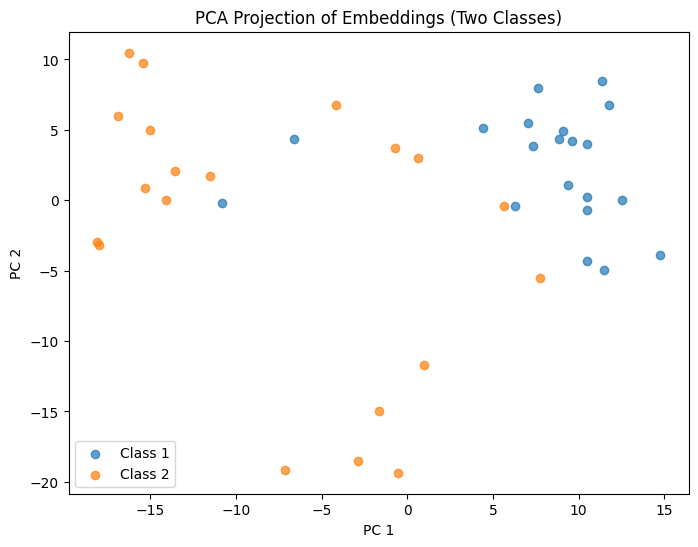

In [ ]:
class1 = "n01443537"
class2 = "n01629819"

imgs, labels = load_images_from_two_classes(
    TRAIN_PATH,
    class1,
    class2,
    train_transforms,
    num_per_class=20
)

plot_two_class_embeddings(model, imgs, labels, device)


**Answer 2**

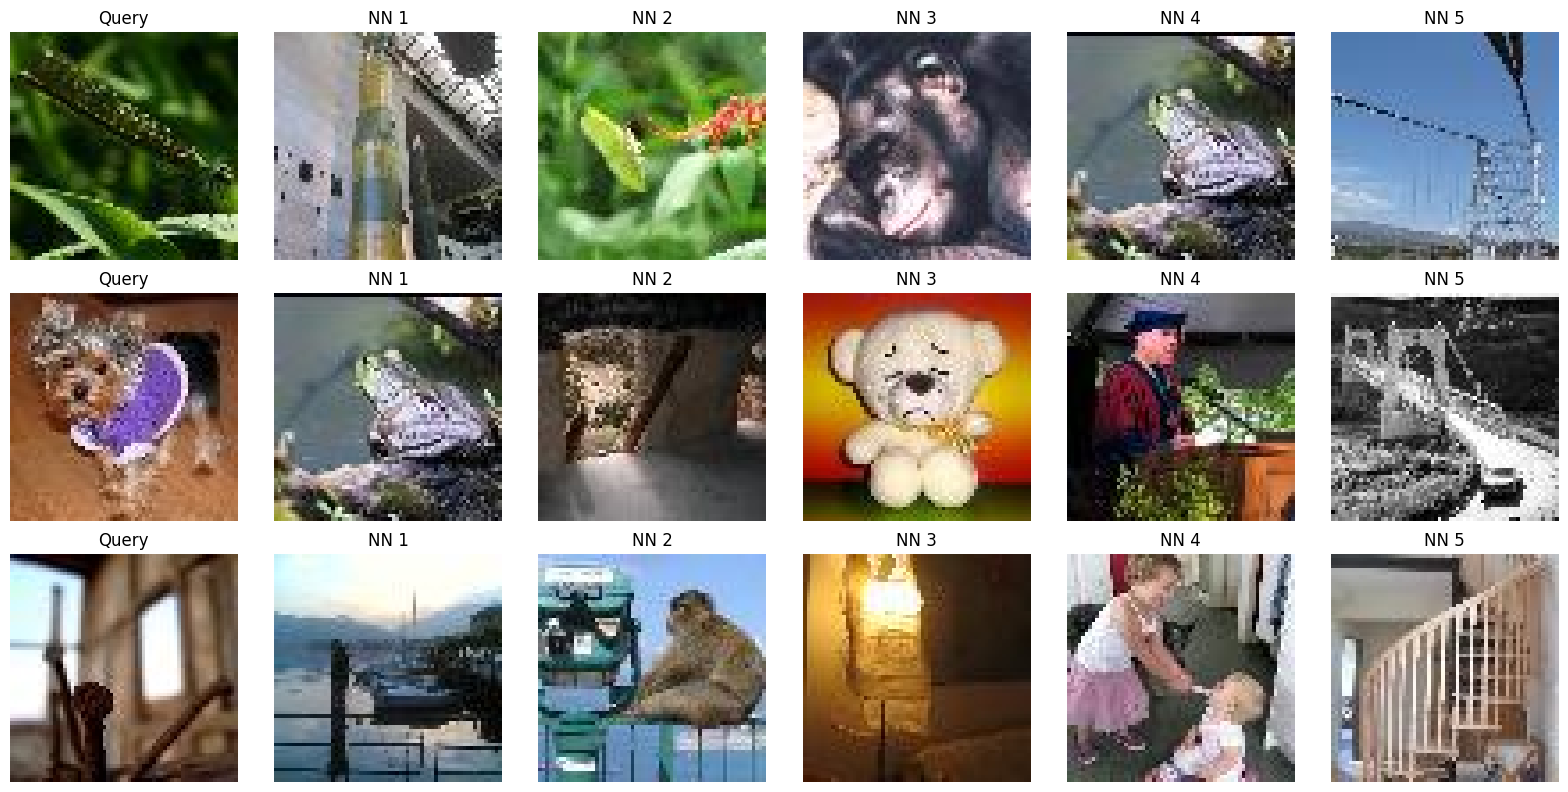

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def mse_dist(a, b):
    # a: [D], b: [N, D] -> returns [N]
    return ((b - a.unsqueeze(0)) ** 2).mean(dim=1)

# ---- take ONE batch from test loader ----
batch_iter = iter(test_loader)
img_orig, img_t = next(batch_iter)         # your test_loader returns (original_img, transformed_img)
img_t = img_t.to(device)

# ---- compute embeddings for the whole batch once ----
with torch.no_grad():
    Z = model(img_t)  # [B, D]

# choose 3 query indices (first 3 for reproducibility; you can randomize if you want)
query_ids = [0, 1, 2]
k = 5

fig, axes = plt.subplots(len(query_ids), k + 1, figsize=(16, 8))

for r, qi in enumerate(query_ids):
    q_emb = Z[qi]                     # [D]
    d = mse_dist(q_emb, Z)            # [B]
    d[qi] = 1e9                       # exclude the query itself
    nn_ids = torch.topk(d, k, largest=False).indices.cpu().tolist()

    # show query (use original image for display)
    axes[r, 0].imshow(img_orig[qi].permute(1, 2, 0))
    axes[r, 0].set_title("Query")
    axes[r, 0].axis("off")

    # show neighbors
    for c, ni in enumerate(nn_ids, start=1):
        axes[r, c].imshow(img_orig[ni].permute(1, 2, 0))
        axes[r, c].set_title(f"NN {c}")
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()
